# ThetreStageAI Dataset — Exploratory Data Analysis (EDA)

This notebook performs a **research-oriented EDA** of the synthetic Bengali theatre dataset used by **ThetreStageAI** for multi-view retrieval augmentation.

### Goals
- Verify dataset size, schema, completeness, and uniqueness.
- Analyze themes, genres, scene types, locations, time, and emotions.
- Measure character, dialogue, blocking, lighting, and sound-cue distributions.
- Quantify dialogue diversity and repetition.
- Validate the three retrieval views: **Scene**, **Blocking**, and **Lighting**.
- Produce paper-ready summary tables and figures.

> **Important dataset note:** the records are synthetic/template-generated for research and RAG prototyping. EDA should therefore report both coverage and limitations, especially repetition or low linguistic diversity.


## 1. Imports and configuration

Only common Python packages are used: `pandas`, `numpy`, and `matplotlib`.  
Figures are saved to `eda_outputs/figures/` at 300 DPI for reuse in a paper.

Install the optional notebook dependencies from the repository root before running the cells:

```bash
python -m pip install -r requirements-notebook.txt
python -m ipykernel install --user --name thetrestageai --display-name \"ThetreStageAI (.venv)\"
```

Then select the **ThetreStageAI (.venv)** kernel and use **Restart Kernel and Run All Cells**.


In [ ]:
from pathlib import Path
import json
import re
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

FIG_DIR = Path("eda_outputs/figures")
TABLE_DIR = Path("eda_outputs/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Figure directory:", FIG_DIR.resolve())
print("Table directory :", TABLE_DIR.resolve())


## 2. Locate and load the dataset

The loader supports either:
1. `Dataset/bangla_natok_500/`, or
2. an extracted `bangla_natok_500/` directory.

This makes the notebook portable between the project folder and a standalone analysis folder.


In [ ]:
ZIP_NAME = "Bangla_Natok_500_MultiView_RAG_Dataset.zip"
DATASET_RELATIVE_PATH = Path(
    "Dataset/bangla_natok_500/bangla_natok_500.jsonl"
)

# Jupyter may start in the repository root, in Notebooks/, or in another
# parent directory. Search upward instead of depending on one working directory.
search_roots = [Path.cwd(), *Path.cwd().parents]
zip_candidates = [root / ZIP_NAME for root in search_roots]
zip_candidates.append(Path("/mnt/data") / ZIP_NAME)
jsonl_candidates = [root / DATASET_RELATIVE_PATH for root in search_roots]
jsonl_candidates.extend(
    root / "bangla_natok_500/bangla_natok_500.jsonl" for root in search_roots
)

dataset_zip = next((p.resolve() for p in zip_candidates if p.is_file()), None)
dataset_jsonl = next((p.resolve() for p in jsonl_candidates if p.is_file()), None)

if dataset_zip is None and dataset_jsonl is None:
    raise FileNotFoundError(
        "Dataset not found. Put Bangla_Natok_500_MultiView_RAG_Dataset.zip "
        "in this repository, beside this notebook, or update DATASET_RELATIVE_PATH."
    )

print("ZIP source   :", dataset_zip)
print("JSONL source :", dataset_jsonl)


In [ ]:
def read_jsonl_text(text: str):
    return [json.loads(line) for line in text.splitlines() if line.strip()]

def read_main_records():
    if dataset_zip is not None:
        inner = "bangla_natok_500/bangla_natok_500.jsonl"
        with zipfile.ZipFile(dataset_zip) as zf:
            return read_jsonl_text(zf.read(inner).decode("utf-8"))
    return read_jsonl_text(dataset_jsonl.read_text(encoding="utf-8"))

def read_retrieval_view(filename: str):
    if dataset_zip is not None:
        inner = f"bangla_natok_500/retrieval_views/{filename}"
        with zipfile.ZipFile(dataset_zip) as zf:
            return read_jsonl_text(zf.read(inner).decode("utf-8"))

    roots = [
        dataset_jsonl.parent / "retrieval_views",
        Path("bangla_natok_500/retrieval_views"),
        Path("Dataset/bangla_natok_500/retrieval_views"),
    ]
    for root in roots:
        p = root / filename
        if p.exists():
            return read_jsonl_text(p.read_text(encoding="utf-8"))
    raise FileNotFoundError(f"Retrieval view not found: {filename}")

records = read_main_records()
scene_docs = read_retrieval_view("scene_view.jsonl")
blocking_docs = read_retrieval_view("blocking_view.jsonl")
lighting_docs = read_retrieval_view("lighting_view.jsonl")
all_view_docs = read_retrieval_view("all_retrieval_views.jsonl")

print(f"Main records      : {len(records):,}")
print(f"Scene documents   : {len(scene_docs):,}")
print(f"Blocking documents: {len(blocking_docs):,}")
print(f"Lighting documents: {len(lighting_docs):,}")
print(f"All retrieval docs: {len(all_view_docs):,}")


## 3. Inspect schema and a sample record


In [ ]:
print("Top-level fields:")
print(list(records[0].keys()))

display(pd.DataFrame([{
    "id": records[0]["id"],
    "title": records[0]["title"],
    "theme": records[0]["theme"],
    "genre": records[0]["genre"],
    "scene_type": records[0]["scene_type"],
    "location": records[0]["location"],
    "time": records[0]["time"],
    "emotion": records[0]["emotion"]["primary"],
    "characters": ", ".join(records[0]["characters"]),
    "dialogue_count": len(records[0]["dialogue"]),
    "blocking_count": len(records[0]["blocking"]),
    "lighting_count": len(records[0]["lighting"]),
    "sound_count": len(records[0]["sound"]),
}]))


## 4. Build an analysis table

Nested lists are converted into record-level numeric features while the original records remain available for detailed analyses.


In [8]:
rows = []

for r in records:
    dialogue_text = " ".join(d.get("text", "") for d in r.get("dialogue", []))

    rows.append({
        "id": r.get("id"),
        "document_type": r.get("document_type"),
        "language": r.get("language"),
        "title": r.get("title"),
        "theme": r.get("theme"),
        "genre": r.get("genre"),
        "scene_type": r.get("scene_type"),
        "location": r.get("location"),
        "time": r.get("time"),
        "emotion": r.get("emotion", {}).get("primary"),
        "emotion_intensity": r.get("emotion", {}).get("intensity"),
        "character_count": len(r.get("characters", [])),
        "dialogue_count": len(r.get("dialogue", [])),
        "dialogue_chars": len(dialogue_text),
        "dialogue_words": len(dialogue_text.split()),
        "stage_direction_count": len(r.get("stage_directions", [])),
        "blocking_count": len(r.get("blocking", [])),
        "lighting_count": len(r.get("lighting", [])),
        "sound_count": len(r.get("sound", [])),
        "summary_chars": len(r.get("summary", "")),
        "license_note": r.get("license_note"),
    })

df = pd.DataFrame(rows)
display(df.head())
print("Shape:", df.shape)


,id,document_type,language,title,theme,genre,scene_type,location,time,emotion,emotion_intensity,character_count,dialogue_count,dialogue_chars,dialogue_words,stage_direction_count,blocking_count,lighting_count,sound_count,summary_chars,license_note
0,natok_001,complete_theatre_example,bn,সাইবার বুলিং - ছোট নাটক 001,সাইবার বুলিং,social_drama,confrontation,বাসস্ট্যান্ড,সকাল,দ্বিধা,0.70,2,6,222,42,2,2,2,2,116,Original synthetic script generated for research/RAG use; not copied from an existing play.
1,natok_002,complete_theatre_example,bn,ভুয়া খবর - ছোট নাটক 002,ভুয়া খবর,family_drama,confrontation,বাসস্ট্যান্ড,বিকেল,উদ্বেগ,0.70,2,6,237,46,2,2,2,2,110,Original synthetic script generated for research/RAG use; not copied from an existing play.
2,natok_003,complete_theatre_example,bn,পরীক্ষার চাপ - ছোট নাটক 003,পরীক্ষার চাপ,student_life,confrontation,শ্রেণিকক্ষ,বিকেল,দ্বিধা,0.79,2,6,221,43,2,2,2,2,110,Original synthetic script generated for research/RAG use; not copied from an existing play.
3,natok_004,complete_theatre_example,bn,মোবাইল আসক্তি - ছোট নাটক 004,মোবাইল আসক্তি,awareness,decision,পার্ক,রাত,উদ্বেগ,0.76,2,6,206,38,2,2,2,2,111,Original synthetic script generated for research/RAG use; not copied from an existing play.
4,natok_005,complete_theatre_example,bn,বন্ধুত্বের পরীক্ষা - ছোট নাটক 005,বন্ধুত্বের পরীক্ষা,emotional_drama,decision,বাসস্ট্যান্ড,সন্ধ্যা,আশা,0.72,2,6,224,40,2,2,2,2,120,Original synthetic script generated for research/RAG use; not copied from an existing play.


Shape: (500, 21)


## 5. Data integrity: missing values, IDs, and duplicate records


In [9]:
integrity = pd.DataFrame({
    "metric": [
        "Total records",
        "Unique record IDs",
        "Duplicate record IDs",
        "Unique titles",
        "Duplicate full rows (flattened table)",
        "Rows with any missing flattened value",
    ],
    "value": [
        len(df),
        df["id"].nunique(),
        int(df["id"].duplicated().sum()),
        df["title"].nunique(),
        int(df.duplicated().sum()),
        int(df.isna().any(axis=1).sum()),
    ],
})
display(integrity)

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if missing.empty:
    print("No missing values found in the flattened record-level fields.")
else:
    display(missing.to_frame("missing_count"))

integrity.to_csv(TABLE_DIR / "dataset_integrity.csv", index=False)


,metric,value
0,Total records,500
1,Unique record IDs,500
2,Duplicate record IDs,0
3,Unique titles,500
4,Duplicate full rows (flattened table),0
5,Rows with any missing flattened value,0


No missing values found in the flattened record-level fields.


## 6. High-level dataset summary


In [10]:
summary_table = pd.DataFrame({
    "Measure": [
        "Records",
        "Themes",
        "Genres",
        "Scene types",
        "Locations",
        "Times of day",
        "Primary emotions",
        "Unique character names",
        "Total dialogue lines",
        "Total blocking cues",
        "Total lighting cues",
        "Total sound cues",
    ],
    "Value": [
        len(df),
        df["theme"].nunique(),
        df["genre"].nunique(),
        df["scene_type"].nunique(),
        df["location"].nunique(),
        df["time"].nunique(),
        df["emotion"].nunique(),
        len({c for r in records for c in r.get("characters", [])}),
        sum(len(r.get("dialogue", [])) for r in records),
        sum(len(r.get("blocking", [])) for r in records),
        sum(len(r.get("lighting", [])) for r in records),
        sum(len(r.get("sound", [])) for r in records),
    ],
})
display(summary_table)
summary_table.to_csv(TABLE_DIR / "high_level_summary.csv", index=False)


,Measure,Value
0,Records,500
1,Themes,15
2,Genres,5
3,Scene types,4
4,Locations,8
5,Times of day,4
6,Primary emotions,5
7,Unique character names,20
8,Total dialogue lines,3000
9,Total blocking cues,1000


## 7. Categorical distributions

These plots show how evenly the synthetic corpus covers major theatre attributes.


/tmp/ipykernel_15821/2714429867.py:14: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/2714429867.py:14: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/2714429867.py:14: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/2714429867.py:14: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/2714429867.py:14: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/2714429867.py:14: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/2714429867.py:14: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipy

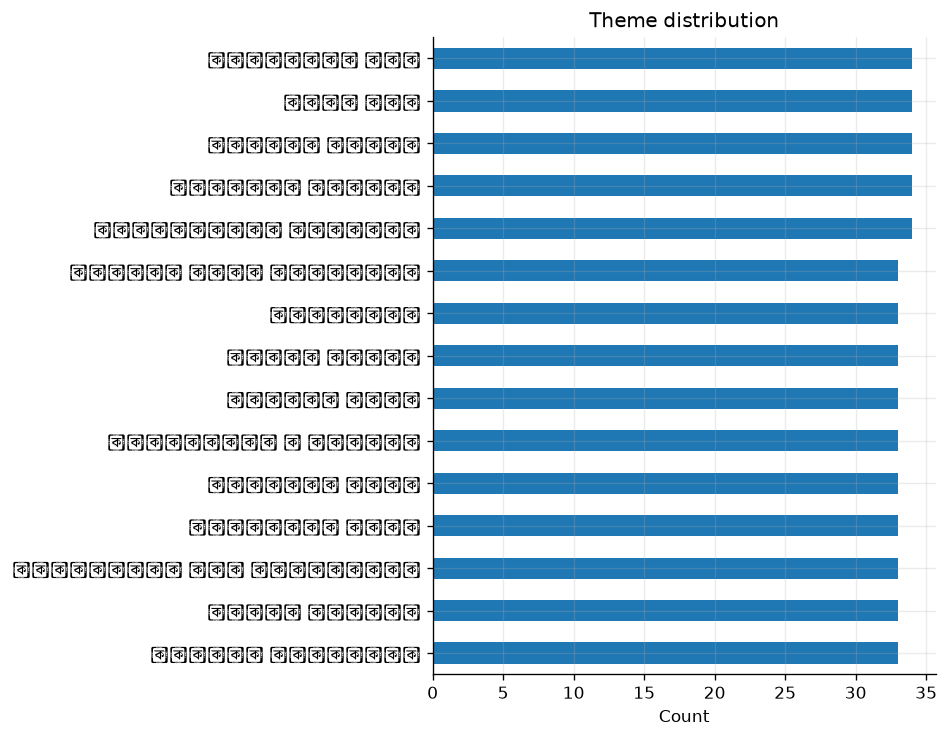

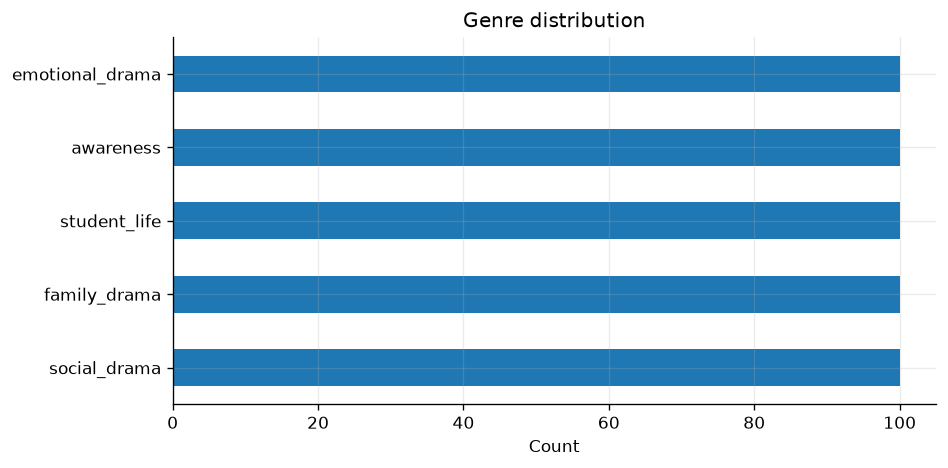

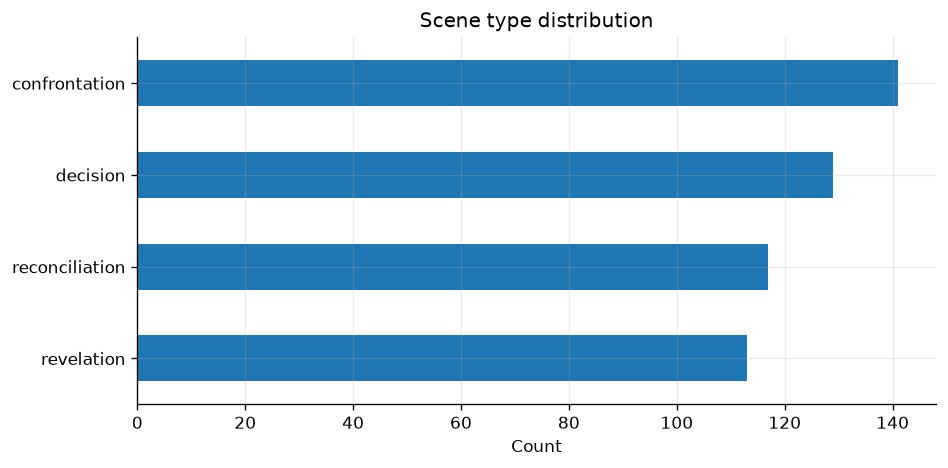

In [11]:
def plot_counts(series, title, xlabel="Count", filename=None, horizontal=True):
    counts = series.value_counts()
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(counts) + 1)))
    if horizontal:
        counts.sort_values().plot(kind="barh", ax=ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("")
    else:
        counts.plot(kind="bar", ax=ax)
        ax.set_ylabel(xlabel)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=35)
    ax.set_title(title)
    fig.tight_layout()
    if filename:
        fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()
    return counts

theme_counts = plot_counts(df["theme"], "Theme distribution", filename="theme_distribution.png")
genre_counts = plot_counts(df["genre"], "Genre distribution", filename="genre_distribution.png")
scene_type_counts = plot_counts(df["scene_type"], "Scene type distribution", filename="scene_type_distribution.png")


In [ ]:
location_counts = plot_counts(df["location"], "Location distribution", filename="location_distribution.png")
time_counts = plot_counts(df["time"], "Time-of-day distribution", filename="time_distribution.png")
emotion_counts = plot_counts(df["emotion"], "Primary emotion distribution", filename="emotion_distribution.png")


## 8. Emotion intensity and record-level content size


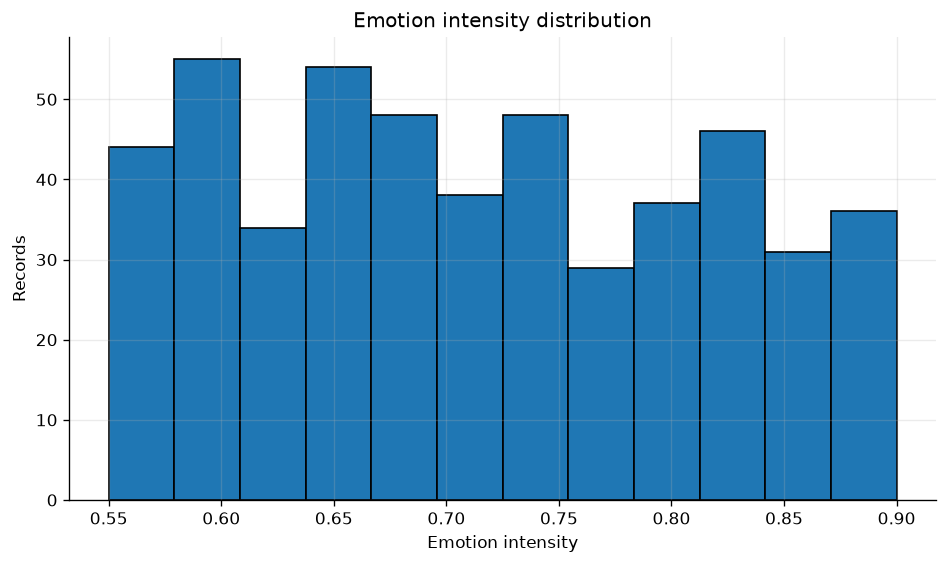

,count,mean,std,min,25%,50%,75%,max
character_count,500.0,2.000,0.000,2.00,2.00,2.000,2.00,2.0
dialogue_count,500.0,6.000,0.000,6.00,6.00,6.000,6.00,6.0
dialogue_chars,500.0,231.510,12.827,197.00,222.00,232.000,240.00,263.0
dialogue_words,500.0,42.776,2.337,38.00,41.00,43.000,44.25,49.0
stage_direction_count,500.0,2.000,0.000,2.00,2.00,2.000,2.00,2.0
blocking_count,500.0,2.000,0.000,2.00,2.00,2.000,2.00,2.0
lighting_count,500.0,2.000,0.000,2.00,2.00,2.000,2.00,2.0
sound_count,500.0,2.000,0.000,2.00,2.00,2.000,2.00,2.0
summary_chars,500.0,115.432,5.837,102.00,111.00,114.000,119.00,134.0
emotion_intensity,500.0,0.714,0.103,0.55,0.63,0.705,0.80,0.9


In [12]:
fig, ax = plt.subplots()
ax.hist(df["emotion_intensity"].dropna(), bins=12, edgecolor="black")
ax.set_title("Emotion intensity distribution")
ax.set_xlabel("Emotion intensity")
ax.set_ylabel("Records")
fig.tight_layout()
fig.savefig(FIG_DIR / "emotion_intensity_distribution.png", bbox_inches="tight")
plt.show()

numeric_cols = [
    "character_count", "dialogue_count", "dialogue_chars", "dialogue_words",
    "stage_direction_count", "blocking_count", "lighting_count", "sound_count",
    "summary_chars", "emotion_intensity"
]
display(df[numeric_cols].describe().T.round(3))
df[numeric_cols].describe().T.to_csv(TABLE_DIR / "numeric_descriptive_statistics.csv")


## 9. Character analysis


,character,record_occurrences
0,তিথি,62
1,তানভীর,58
2,নাঈম,56
3,সামি,55
4,সুমাইয়া,55
5,রাহাত,55
6,রাফি,54
7,মৌ,53
8,নীরা,52
9,আফসানা,51


/tmp/ipykernel_15821/240626144.py:13: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/240626144.py:13: UserWarning: Glyph 2489 (\N{BENGALI LETTER HA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/240626144.py:13: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/240626144.py:13: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/240626144.py:13: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/240626144.py:13: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/240626144.py:13: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykern

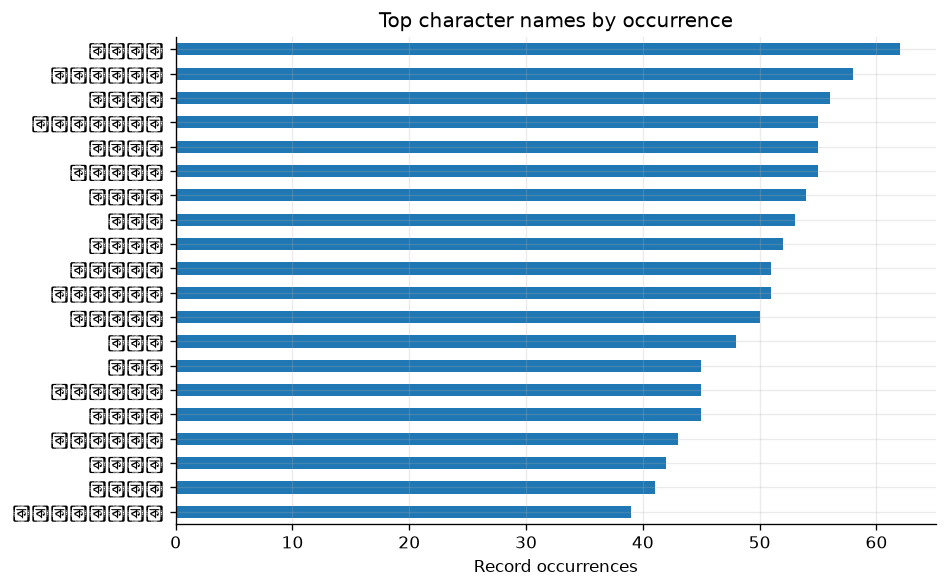

In [13]:
character_counter = Counter(c for r in records for c in r.get("characters", []))
character_df = pd.DataFrame(character_counter.most_common(), columns=["character", "record_occurrences"])

display(character_df.head(20))

fig, ax = plt.subplots(figsize=(8, 5))
character_df.head(20).sort_values("record_occurrences").plot(
    x="character", y="record_occurrences", kind="barh", legend=False, ax=ax
)
ax.set_title("Top character names by occurrence")
ax.set_xlabel("Record occurrences")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "character_frequency.png", bbox_inches="tight")
plt.show()

character_df.to_csv(TABLE_DIR / "character_frequency.csv", index=False)


## 10. Dialogue diversity and repetition

This is an important quality analysis for a synthetic/template-generated corpus.  
A high repeated-line ratio indicates that retrieval can be useful for controlled demonstrations but may not provide broad linguistic diversity.


In [14]:
dialogue_rows = []
for r in records:
    for d in r.get("dialogue", []):
        dialogue_rows.append({
            "source_id": r["id"],
            "theme": r["theme"],
            "genre": r["genre"],
            "dialogue_id": d.get("id"),
            "speaker": d.get("speaker"),
            "text": d.get("text", ""),
            "char_length": len(d.get("text", "")),
            "word_length": len(d.get("text", "").split()),
        })

dialogue_df = pd.DataFrame(dialogue_rows)

total_dialogues = len(dialogue_df)
unique_dialogues = dialogue_df["text"].nunique()
duplicate_dialogues = total_dialogues - unique_dialogues
unique_ratio = unique_dialogues / total_dialogues if total_dialogues else np.nan
duplicate_ratio = duplicate_dialogues / total_dialogues if total_dialogues else np.nan

dialogue_diversity = pd.DataFrame({
    "Metric": [
        "Total dialogue lines",
        "Unique dialogue texts",
        "Repeated dialogue instances",
        "Unique dialogue ratio",
        "Repeated dialogue ratio",
    ],
    "Value": [
        total_dialogues,
        unique_dialogues,
        duplicate_dialogues,
        unique_ratio,
        duplicate_ratio,
    ],
})
display(dialogue_diversity)

top_dialogues = dialogue_df["text"].value_counts().head(15).rename_axis("dialogue").reset_index(name="frequency")
display(top_dialogues)

dialogue_diversity.to_csv(TABLE_DIR / "dialogue_diversity.csv", index=False)
top_dialogues.to_csv(TABLE_DIR / "top_repeated_dialogues.csv", index=False)


,Metric,Value
0,Total dialogue lines,3000.000
1,Unique dialogue texts,39.000
2,Repeated dialogue instances,2961.000
3,Unique dialogue ratio,0.013
4,Repeated dialogue ratio,0.987


,dialogue,frequency
0,আমরা ভুল থেকে শিখলে তবেই পরিবর্তন আসে।,142
1,এবার কাজ দিয়ে প্রমাণ করো।,122
2,"সত্য বলা কঠিন, কিন্তু সেখান থেকেই নতুন শুরু হয়।",120
3,সমস্যার মুখোমুখি হওয়াটাই প্রথম সাহস।,116
4,এভাবে পালিয়ে গেলে সমাধান হবে না।,111
5,আজ তোমাকে খুব অদ্ভুত লাগছে।,111
6,"আমি ভুল করেছি, কিন্তু ইচ্ছে করে না।",107
7,কালই সবার সামনে সত্যটা বলব।,106
8,"ঠিক আছে, আমি সব খুলে বলব।",104
9,এখন কথা বলার মতো অবস্থায় নেই।,103


/tmp/ipykernel_15821/3045723690.py:7: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/3045723690.py:7: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/3045723690.py:7: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/3045723690.py:7: UserWarning: Glyph 2477 (\N{BENGALI LETTER BHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/3045723690.py:7: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/3045723690.py:7: UserWarning: Glyph 2459 (\N{BENGALI LETTER CHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/3045723690.py:7: UserWarning: Glyph 2456 (\N{BENGALI LETTER GHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipyke

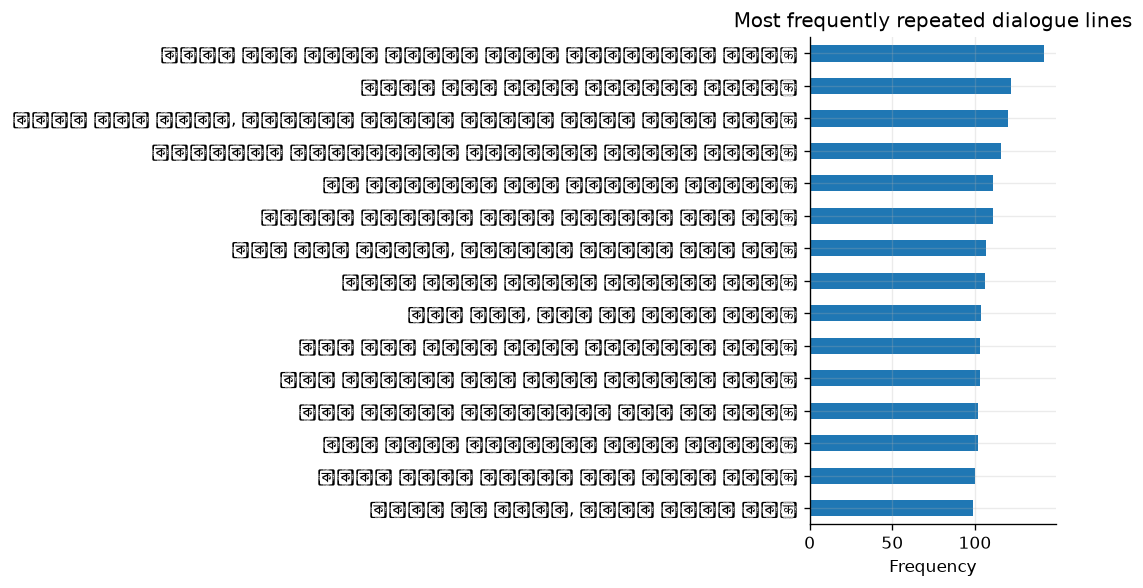

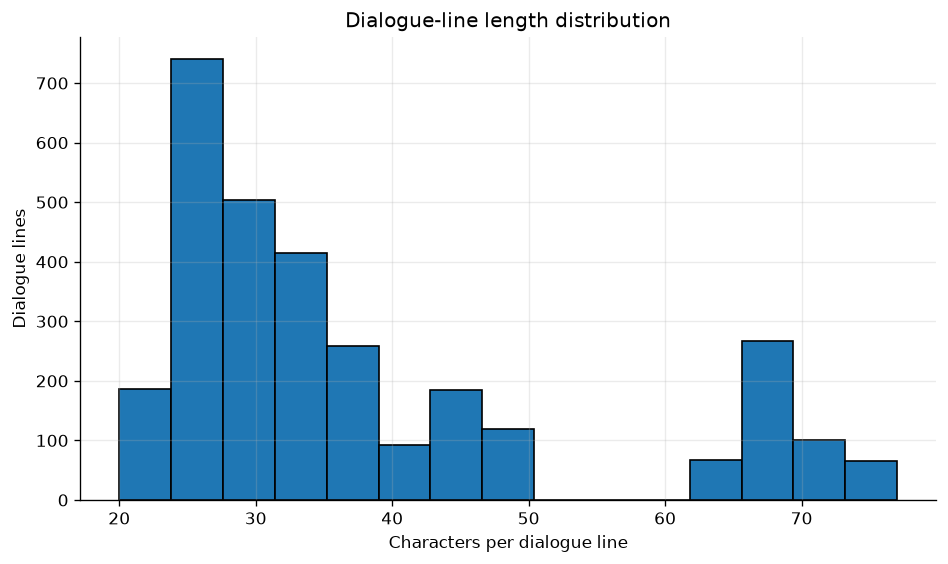

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
top_plot = top_dialogues.copy().sort_values("frequency")
top_plot.plot(x="dialogue", y="frequency", kind="barh", legend=False, ax=ax)
ax.set_title("Most frequently repeated dialogue lines")
ax.set_xlabel("Frequency")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "top_repeated_dialogues.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots()
ax.hist(dialogue_df["char_length"], bins=15, edgecolor="black")
ax.set_title("Dialogue-line length distribution")
ax.set_xlabel("Characters per dialogue line")
ax.set_ylabel("Dialogue lines")
fig.tight_layout()
fig.savefig(FIG_DIR / "dialogue_length_distribution.png", bbox_inches="tight")
plt.show()


## 11. Blocking analysis

Blocking is analyzed by movement action, origin zone, destination zone, and trigger.


,count
action,
walk_slowly,500
step_forward,500


,count
trigger,
D01,500
D03,500


,from_count,to_count
DSR,127,96
USC,126,100
DSC,116,126
CSL,115,122
USL,114,124
USR,103,94
DSL,103,138
CSR,101,112
CSC,95,88


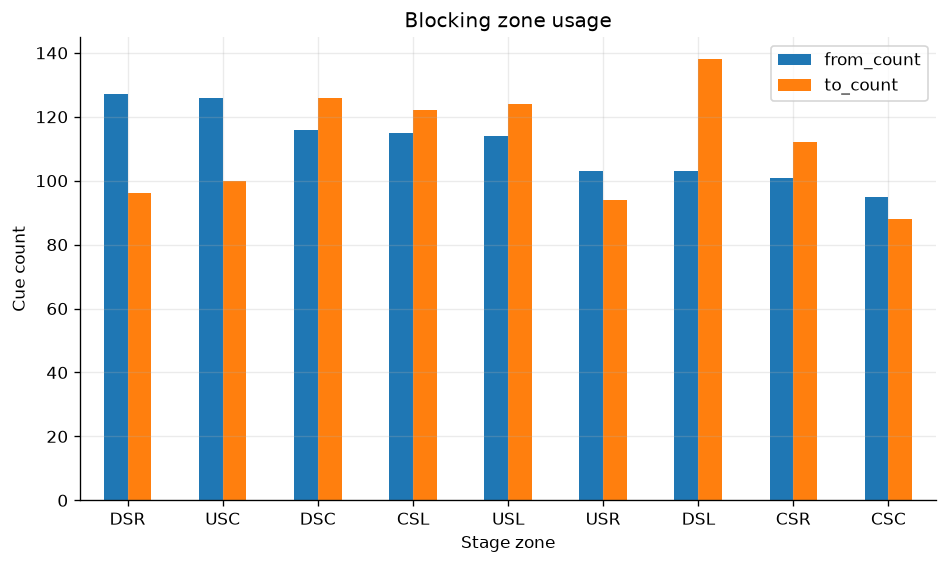

In [16]:
blocking_rows = []
for r in records:
    for b in r.get("blocking", []):
        blocking_rows.append({
            "source_id": r["id"],
            "theme": r["theme"],
            "actor": b.get("actor"),
            "from_zone": b.get("from"),
            "to_zone": b.get("to"),
            "action": b.get("action"),
            "trigger": b.get("trigger"),
        })

blocking_df = pd.DataFrame(blocking_rows)

display(blocking_df["action"].value_counts().to_frame("count"))
display(blocking_df["trigger"].value_counts().to_frame("count"))

zone_table = pd.concat([
    blocking_df["from_zone"].value_counts().rename("from_count"),
    blocking_df["to_zone"].value_counts().rename("to_count"),
], axis=1).fillna(0).astype(int)

display(zone_table)

fig, ax = plt.subplots(figsize=(8, 4.8))
zone_table.plot(kind="bar", ax=ax)
ax.set_title("Blocking zone usage")
ax.set_xlabel("Stage zone")
ax.set_ylabel("Cue count")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "blocking_zone_usage.png", bbox_inches="tight")
plt.show()

zone_table.to_csv(TABLE_DIR / "blocking_zone_usage.csv")


## 12. Lighting analysis

The lighting EDA checks fixture usage, focus zones, color names, intensity, fade duration, and RGB validity.


In [17]:
lighting_rows = []
for r in records:
    for l in r.get("lighting", []):
        rgb = l.get("rgb", [None, None, None])
        lighting_rows.append({
            "source_id": r["id"],
            "theme": r["theme"],
            "cue_id": l.get("cue_id"),
            "trigger": l.get("trigger"),
            "fixture": l.get("fixture"),
            "focus_zone": l.get("focus_zone"),
            "color_name": l.get("color_name"),
            "r": rgb[0] if len(rgb) > 0 else None,
            "g": rgb[1] if len(rgb) > 1 else None,
            "b": rgb[2] if len(rgb) > 2 else None,
            "intensity": l.get("intensity"),
            "fade_seconds": l.get("fade_seconds"),
        })

lighting_df = pd.DataFrame(lighting_rows)

display(lighting_df["fixture"].value_counts().to_frame("count"))
display(lighting_df["color_name"].value_counts().to_frame("count"))
display(lighting_df["focus_zone"].value_counts().to_frame("count"))

rgb_valid = (
    lighting_df[["r", "g", "b"]].ge(0).all(axis=1) &
    lighting_df[["r", "g", "b"]].le(255).all(axis=1)
)
intensity_valid = lighting_df["intensity"].between(0, 100, inclusive="both")
fade_valid = lighting_df["fade_seconds"].ge(0)

lighting_quality = pd.DataFrame({
    "Metric": ["Lighting cues", "Valid RGB cues", "Valid intensity cues", "Non-negative fade cues"],
    "Count": [len(lighting_df), int(rgb_valid.sum()), int(intensity_valid.sum()), int(fade_valid.sum())],
})
display(lighting_quality)
lighting_quality.to_csv(TABLE_DIR / "lighting_quality_checks.csv", index=False)


,count
fixture,
PAR01,500
PAR02,500


,count
color_name,
warm_white,219
soft_amber,216
deep_blue,195
cool_blue,187
muted_red,183


,count
focus_zone,
CSC,544
DSL,69
DSC,63
USL,62
CSL,61
CSR,56
USC,50
DSR,48
USR,47


,Metric,Count
0,Lighting cues,1000
1,Valid RGB cues,1000
2,Valid intensity cues,1000
3,Non-negative fade cues,1000


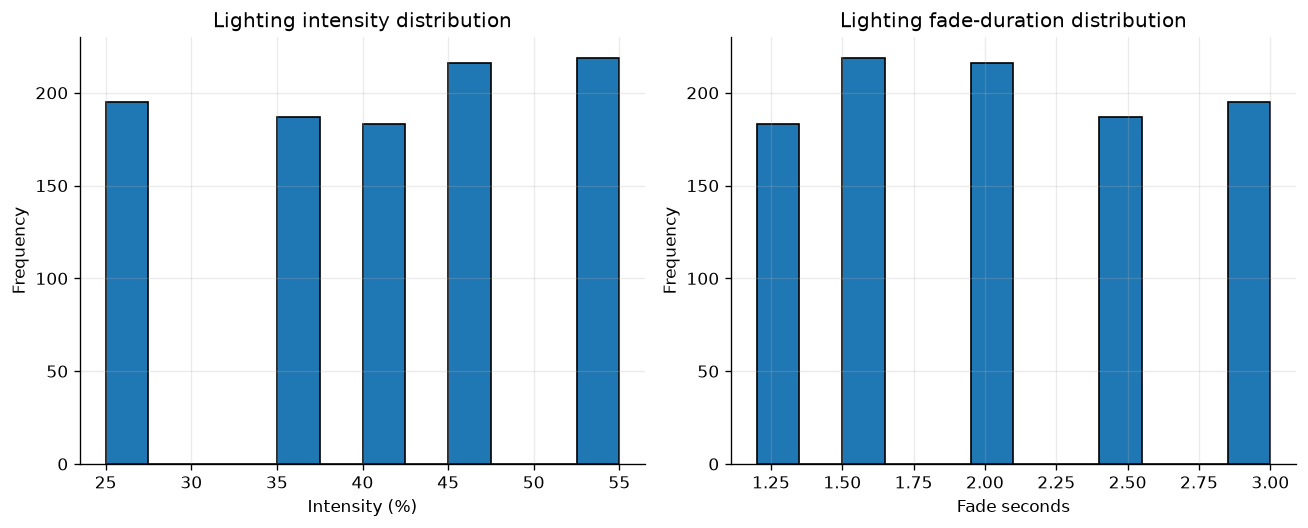

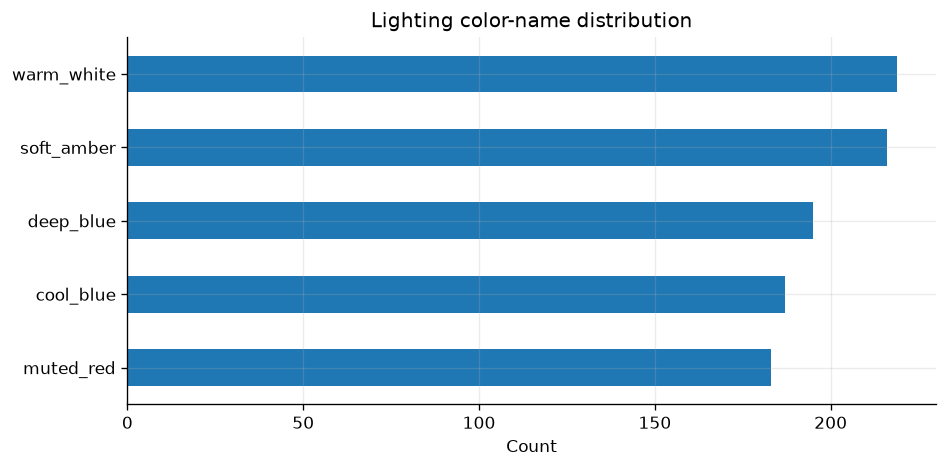

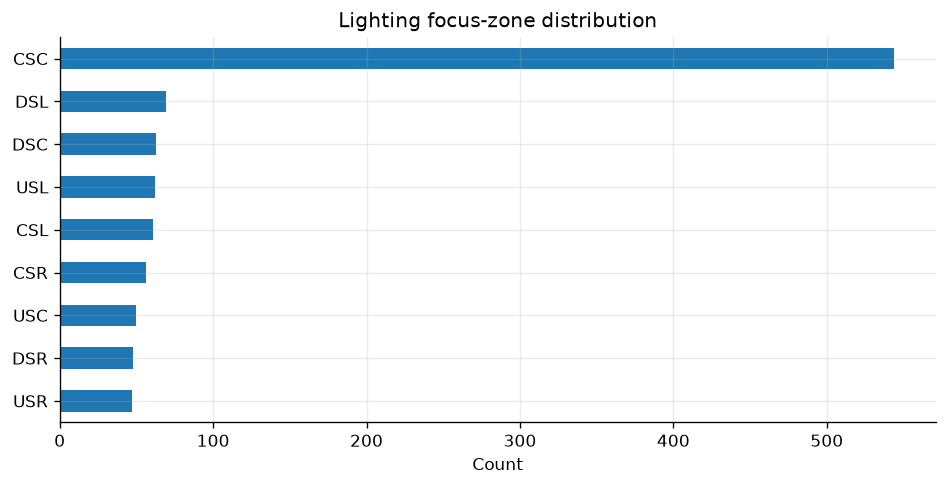

focus_zone
CSC    544
DSL     69
DSC     63
USL     62
CSL     61
CSR     56
USC     50
DSR     48
USR     47
Name: count, dtype: int64

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
lighting_df["intensity"].plot(kind="hist", bins=12, edgecolor="black", ax=axes[0])
axes[0].set_title("Lighting intensity distribution")
axes[0].set_xlabel("Intensity (%)")

lighting_df["fade_seconds"].plot(kind="hist", bins=12, edgecolor="black", ax=axes[1])
axes[1].set_title("Lighting fade-duration distribution")
axes[1].set_xlabel("Fade seconds")

fig.tight_layout()
fig.savefig(FIG_DIR / "lighting_intensity_fade.png", bbox_inches="tight")
plt.show()

plot_counts(lighting_df["color_name"], "Lighting color-name distribution", filename="lighting_color_distribution.png")
plot_counts(lighting_df["focus_zone"], "Lighting focus-zone distribution", filename="lighting_focus_zone_distribution.png")


## 13. Sound-cue analysis


In [19]:
sound_rows = []
for r in records:
    for s in r.get("sound", []):
        sound_rows.append({
            "source_id": r["id"],
            "theme": r["theme"],
            "cue_id": s.get("cue_id"),
            "trigger": s.get("trigger"),
            "type": s.get("type"),
            "volume": s.get("volume"),
        })

sound_df = pd.DataFrame(sound_rows)

display(sound_df["type"].value_counts().to_frame("count"))
display(sound_df["trigger"].value_counts().head(15).to_frame("count"))
display(sound_df["volume"].describe().to_frame().T)

sound_df["type"].value_counts().to_csv(TABLE_DIR / "sound_type_distribution.csv")


,count
type,
low_ambient,500
soft_resolve,500


,count
trigger,
scene_start,500
D06,500


,count,mean,std,min,25%,50%,75%,max
volume,1000.0,0.175,0.025013,0.15,0.15,0.175,0.2,0.2


## 14. Cross-variable relationships

Cross-tabulations can reveal whether synthetic generation is balanced or strongly coupled across categories.


In [20]:
theme_genre = pd.crosstab(df["theme"], df["genre"])
emotion_scene = pd.crosstab(df["emotion"], df["scene_type"])

display(Markdown("### Theme × Genre"))
display(theme_genre)

display(Markdown("### Emotion × Scene Type"))
display(emotion_scene)

theme_genre.to_csv(TABLE_DIR / "theme_by_genre.csv")
emotion_scene.to_csv(TABLE_DIR / "emotion_by_scene_type.csv")


### Theme × Genre

genre,awareness,emotional_drama,family_drama,social_drama,student_life
theme,,,,,
অনলাইন প্রতারণা,0,0,33,0,0
দারিদ্র্য ও শিক্ষা,0,0,0,33,0
নারীর শিক্ষা,0,0,0,0,33
পরিবেশ দূষণ,0,33,0,0,0
পরীক্ষার চাপ,0,0,0,0,34
পারিবারিক ভুল বোঝাবুঝি,0,0,0,33,0
পুরোনো চিঠি,0,0,0,0,33
বন্ধুত্বের পরীক্ষা,0,34,0,0,0
বিশ্বাস ভঙ্গ,0,0,33,0,0


### Emotion × Scene Type

scene_type,confrontation,decision,reconciliation,revelation
emotion,,,,
আশা,27,23,25,18
উদ্বেগ,26,28,23,26
দুঃখ,32,33,26,31
দ্বিধা,30,33,24,20
রাগ,26,12,19,18


/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_

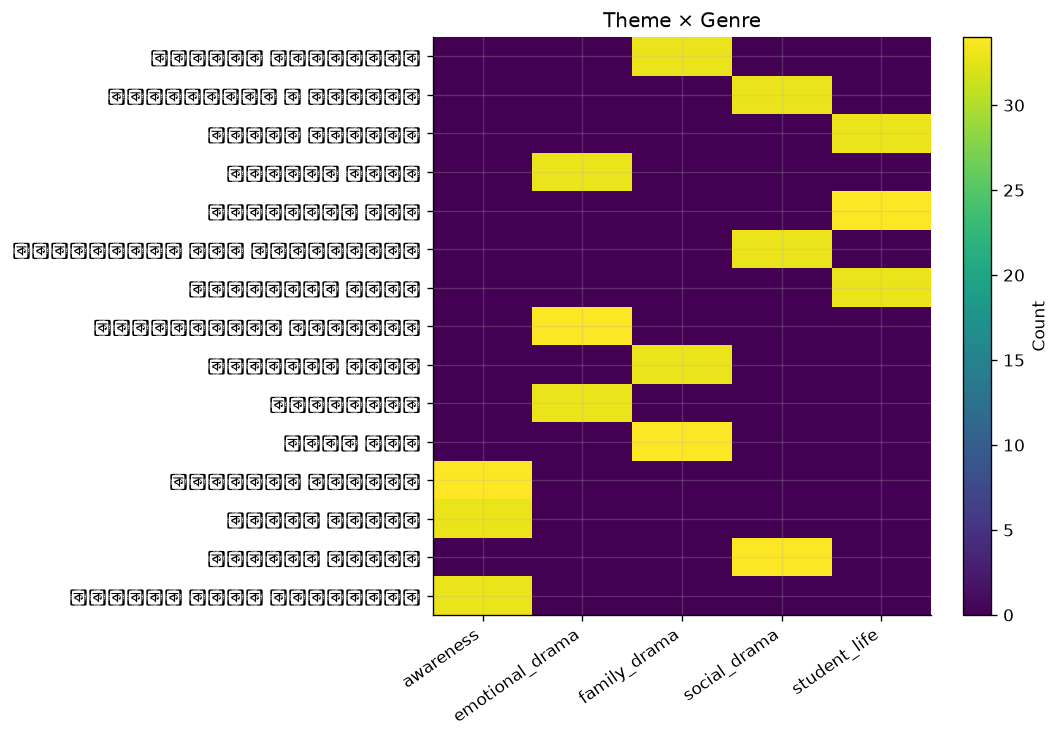

/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2441 (\N{BENGALI LETTER U}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2470 (\N{BENGALI LETTER DA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2455 (\N{BENGALI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_15821/557778743.py:10: UserWarning: Glyph 2454 (\N{BENGALI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykern

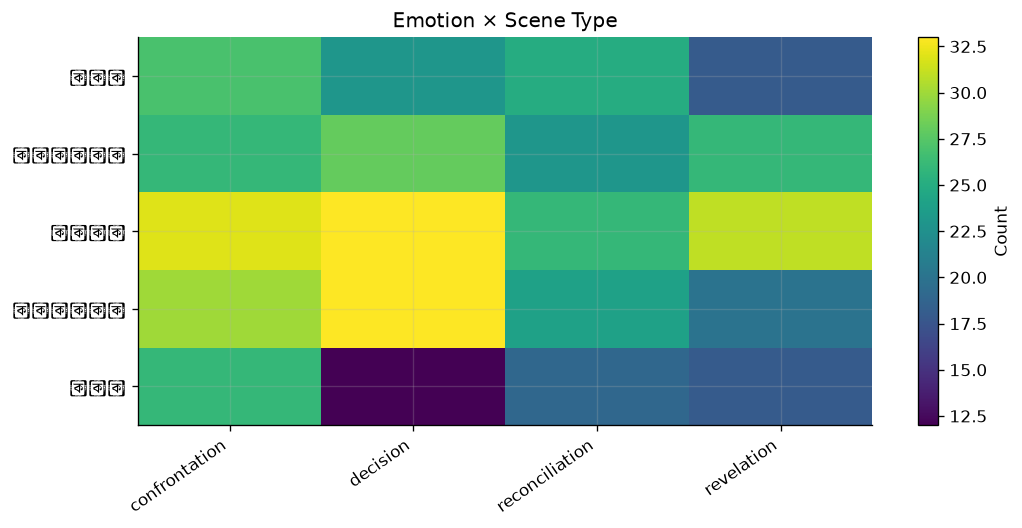

In [21]:
def plot_crosstab_heatmap(table, title, filename):
    fig, ax = plt.subplots(figsize=(9, max(4.5, 0.35 * len(table.index) + 1)))
    im = ax.imshow(table.values, aspect="auto")
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Count")
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()

plot_crosstab_heatmap(theme_genre, "Theme × Genre", "theme_genre_heatmap.png")
plot_crosstab_heatmap(emotion_scene, "Emotion × Scene Type", "emotion_scene_type_heatmap.png")


## 15. Multi-view retrieval dataset validation

ThetreStageAI augments Gemini using three retrieval views.  
This section checks:
- document counts,
- unique view IDs,
- unique search text,
- source-ID coverage,
- whether each source contributes exactly one Scene, Blocking, and Lighting view.


In [22]:
views = {
    "scene": scene_docs,
    "blocking": blocking_docs,
    "lighting": lighting_docs,
    "all": all_view_docs,
}

view_summary = []
for name, docs in views.items():
    ids = [d.get("id") for d in docs]
    source_ids = [d.get("source_id") for d in docs]
    search_texts = [d.get("search_text", "") for d in docs]

    view_summary.append({
        "view": name,
        "documents": len(docs),
        "unique_ids": len(set(ids)),
        "unique_source_ids": len(set(source_ids)),
        "unique_search_texts": len(set(search_texts)),
        "mean_search_text_chars": round(float(np.mean([len(x) for x in search_texts])), 1),
    })

view_summary_df = pd.DataFrame(view_summary)
display(view_summary_df)
view_summary_df.to_csv(TABLE_DIR / "retrieval_view_summary.csv", index=False)


,view,documents,unique_ids,unique_source_ids,unique_search_texts,mean_search_text_chars
0,scene,500,500,500,500,719.3
1,blocking,500,500,500,500,514.0
2,lighting,500,500,500,500,475.4
3,all,1500,1500,500,1500,569.6


In [23]:
all_views_df = pd.DataFrame([{
    "id": d.get("id"),
    "view_type": d.get("view_type"),
    "source_id": d.get("source_id"),
    "search_text_chars": len(d.get("search_text", "")),
    "metadata_present": isinstance(d.get("metadata"), dict) and len(d.get("metadata", {})) > 0,
    "payload_present": isinstance(d.get("payload"), dict) and len(d.get("payload", {})) > 0,
} for d in all_view_docs])

source_view_counts = pd.crosstab(all_views_df["source_id"], all_views_df["view_type"])

print("Sources represented in all views:", len(source_view_counts))
display(source_view_counts.head())

expected_views = {"scene", "blocking", "lighting"}
sources_with_exact_three = sum(
    set(row[row > 0].index) == expected_views and int(row.sum()) == 3
    for _, row in source_view_counts.iterrows()
)

print(f"Sources with exactly one Scene + Blocking + Lighting document: {sources_with_exact_three}/{len(source_view_counts)}")
print("Metadata present in all docs:", bool(all_views_df["metadata_present"].all()))
print("Payload present in all docs :", bool(all_views_df["payload_present"].all()))


Sources represented in all views: 500


view_type,blocking,lighting,scene
source_id,,,
natok_001,1,1,1
natok_002,1,1,1
natok_003,1,1,1
natok_004,1,1,1
natok_005,1,1,1


Sources with exactly one Scene + Blocking + Lighting document: 500/500
Metadata present in all docs: True
Payload present in all docs : True


,count,mean,std,min,median,max
view_type,,,,,,
blocking,500,514.0,13.5,483,513.0,555
lighting,500,475.4,6.6,460,475.0,495
scene,500,719.3,23.3,657,718.5,780


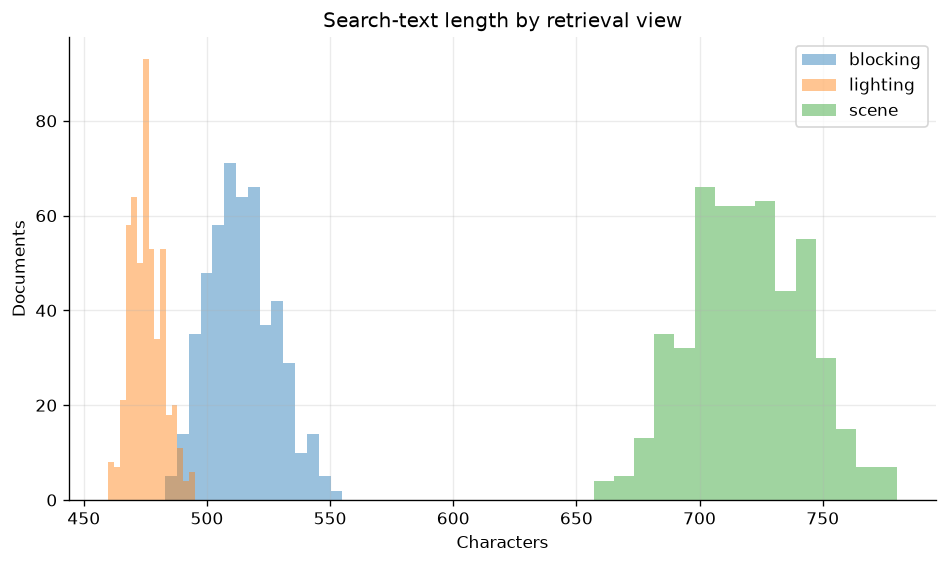

In [24]:
view_lengths = all_views_df.groupby("view_type")["search_text_chars"].agg(["count", "mean", "std", "min", "median", "max"]).round(1)
display(view_lengths)
view_lengths.to_csv(TABLE_DIR / "retrieval_search_text_lengths.csv")

fig, ax = plt.subplots(figsize=(8, 4.8))
for view_type, group in all_views_df.groupby("view_type"):
    ax.hist(group["search_text_chars"], bins=15, alpha=0.45, label=view_type)
ax.set_title("Search-text length by retrieval view")
ax.set_xlabel("Characters")
ax.set_ylabel("Documents")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "retrieval_view_text_lengths.png", bbox_inches="tight")
plt.show()


## 16. Dataset-quality checks for RAG use

The checks below are particularly relevant before reporting experimental results:
- fixed structural counts,
- dialogue-template repetition,
- synthetic-data license note,
- retrieval-view alignment.


In [25]:
all_dialogue_texts = [d["text"] for r in records for d in r.get("dialogue", [])]
all_summaries = [r.get("summary", "") for r in records]
license_notes = {r.get("license_note") for r in records}

quality_checks = pd.DataFrame([
    ["All IDs unique", df["id"].nunique() == len(df)],
    ["All records Bengali (bn)", set(df["language"].dropna()) == {"bn"}],
    ["Every record has a license note", df["license_note"].notna().all()],
    ["All records have 2 characters", (df["character_count"] == 2).all()],
    ["All records have 6 dialogues", (df["dialogue_count"] == 6).all()],
    ["All records have 2 blocking cues", (df["blocking_count"] == 2).all()],
    ["All records have 2 lighting cues", (df["lighting_count"] == 2).all()],
    ["All records have 2 sound cues", (df["sound_count"] == 2).all()],
    ["All retrieval view IDs unique", all_views_df["id"].nunique() == len(all_views_df)],
    ["All retrieval source IDs covered", all_views_df["source_id"].nunique() == df["id"].nunique()],
], columns=["Check", "Passed"])

display(quality_checks)

print("Distinct license notes:", len(license_notes))
for note in sorted(x for x in license_notes if x):
    print("-", note)

print()
print(f"Unique dialogue texts : {len(set(all_dialogue_texts)):,} / {len(all_dialogue_texts):,}")
print(f"Unique summary texts  : {len(set(all_summaries)):,} / {len(all_summaries):,}")


,Check,Passed
0,All IDs unique,True
1,All records Bengali (bn),True
2,Every record has a license note,True
3,All records have 2 characters,True
4,All records have 6 dialogues,True
5,All records have 2 blocking cues,True
6,All records have 2 lighting cues,True
7,All records have 2 sound cues,True
8,All retrieval view IDs unique,True
9,All retrieval source IDs covered,True


Distinct license notes: 1
- Original synthetic script generated for research/RAG use; not copied from an existing play.

Unique dialogue texts : 39 / 3,000
Unique summary texts  : 497 / 500


## 17. Paper-ready EDA summary

The following cell automatically generates a concise evidence-based summary from the loaded data.


In [26]:
n_records = len(df)
n_themes = df["theme"].nunique()
n_genres = df["genre"].nunique()
n_scene_types = df["scene_type"].nunique()
n_locations = df["location"].nunique()
n_emotions = df["emotion"].nunique()
n_characters = len(character_counter)

total_dialogues = len(dialogue_df)
unique_dialogues = dialogue_df["text"].nunique()
repeat_pct = 100 * (1 - unique_dialogues / total_dialogues)

fixed_structure = (
    df["character_count"].nunique() == 1 and
    df["dialogue_count"].nunique() == 1 and
    df["blocking_count"].nunique() == 1 and
    df["lighting_count"].nunique() == 1
)

summary_md = f"""
### Key findings

- The corpus contains **{n_records:,} synthetic Bengali theatre records** spanning **{n_themes} themes**, **{n_genres} genres**, **{n_scene_types} scene types**, **{n_locations} locations**, and **{n_emotions} primary emotions**.
- It uses **{n_characters} unique character names**.
- The corpus contains **{total_dialogues:,} dialogue lines**, but only **{unique_dialogues:,} unique dialogue texts**; approximately **{repeat_pct:.1f}%** of dialogue instances repeat a line that occurs elsewhere.
- Structural composition is {'highly regular/fixed' if fixed_structure else 'variable'}: the modal record contains **{int(df['character_count'].mode()[0])} characters**, **{int(df['dialogue_count'].mode()[0])} dialogues**, **{int(df['blocking_count'].mode()[0])} blocking cues**, and **{int(df['lighting_count'].mode()[0])} lighting cues**.
- Multi-view retrieval contains **{len(scene_docs):,} Scene**, **{len(blocking_docs):,} Blocking**, and **{len(lighting_docs):,} Lighting documents**, for **{len(all_view_docs):,} retrieval documents** in total.
- The data are appropriate for **controlled RAG pipeline development and retrieval experiments**, but the high dialogue repetition and fixed synthetic structure should be reported as limitations when discussing linguistic diversity or real-world generalization.
"""

display(Markdown(summary_md))



### Key findings

- The corpus contains **500 synthetic Bengali theatre records** spanning **15 themes**, **5 genres**, **4 scene types**, **8 locations**, and **5 primary emotions**.
- It uses **20 unique character names**.
- The corpus contains **3,000 dialogue lines**, but only **39 unique dialogue texts**; approximately **98.7%** of dialogue instances repeat a line that occurs elsewhere.
- Structural composition is highly regular/fixed: the modal record contains **2 characters**, **6 dialogues**, **2 blocking cues**, and **2 lighting cues**.
- Multi-view retrieval contains **500 Scene**, **500 Blocking**, and **500 Lighting documents**, for **1,500 retrieval documents** in total.
- The data are appropriate for **controlled RAG pipeline development and retrieval experiments**, but the high dialogue repetition and fixed synthetic structure should be reported as limitations when discussing linguistic diversity or real-world generalization.


## 18. Compact table for a research paper


In [27]:
paper_stats = pd.DataFrame([
    ["Theatre records", len(df)],
    ["Themes", df["theme"].nunique()],
    ["Genres", df["genre"].nunique()],
    ["Scene types", df["scene_type"].nunique()],
    ["Locations", df["location"].nunique()],
    ["Primary emotions", df["emotion"].nunique()],
    ["Unique character names", len(character_counter)],
    ["Dialogue lines", len(dialogue_df)],
    ["Unique dialogue texts", dialogue_df["text"].nunique()],
    ["Blocking cues", len(blocking_df)],
    ["Lighting cues", len(lighting_df)],
    ["Sound cues", len(sound_df)],
    ["Scene retrieval documents", len(scene_docs)],
    ["Blocking retrieval documents", len(blocking_docs)],
    ["Lighting retrieval documents", len(lighting_docs)],
    ["Total retrieval documents", len(all_view_docs)],
], columns=["Statistic", "Value"])

display(paper_stats)
paper_stats.to_csv(TABLE_DIR / "paper_dataset_statistics.csv", index=False)

print("Saved:", TABLE_DIR / "paper_dataset_statistics.csv")


,Statistic,Value
0,Theatre records,500
1,Themes,15
2,Genres,5
3,Scene types,4
4,Locations,8
5,Primary emotions,5
6,Unique character names,20
7,Dialogue lines,3000
8,Unique dialogue texts,39
9,Blocking cues,1000


Saved: eda_outputs/tables/paper_dataset_statistics.csv


## 19. Recommended interpretation for the paper

When writing the dataset section, distinguish between **coverage** and **diversity**:

- **Coverage:** multiple themes, genres, locations, emotions, blocking zones, and lighting configurations are represented.
- **Structural consistency:** each synthetic example follows a predictable schema, which is useful for controlled multi-view retrieval and validation.
- **Linguistic limitation:** dialogue reuse is high, so the corpus should not be presented as a large naturally diverse Bengali theatre corpus.
- **RAG role:** the dataset is used as an external retrieval knowledge base; it **does not train or fine-tune Gemini**.
- **Future improvement:** add licensed/human-authored Bengali theatre scenes and expert-validated blocking/lighting examples for stronger ecological validity.

This wording avoids overstating what a synthetic 500-record dataset can demonstrate.
